<a href="https://colab.research.google.com/github/pandeyp84/Deep-Learning-Tutorials/blob/main/CNN_Tutorial_3_IITBH_SEM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍎 CNN Architecture with PyTorch
## A Complete Guide: From Custom Datasets to Convolutional Neural Networks

---

### 📚 What You'll Learn in This Notebook:
1. **Setting up the environment** – Installing and importing required libraries
2. **Custom Dataset & DataLoaders** – Loading your own fruit classification images
3. **CNN Layers in Detail** – Convolutional layers, activation functions, pooling layers
4. **Building a CNN Architecture** – Step-by-step construction
5. **Training the Model** – Loss functions, optimizers, training loop
6. **Evaluation & Visualization** – Accuracy, confusion matrix, feature maps
7. **In-Class Assignments** – Practice exercises to solidify your understanding

---

> 💡 **Prerequisites:** Basic Python, NumPy, and familiarity with neural network concepts.

---

## 📦 Section 1: Environment Setup

First, let's install and import all necessary libraries.

In [ ]:
# Install required libraries (run once)
# !pip install torch torchvision matplotlib numpy pillow scikit-learn seaborn

In [ ]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

# ─── PyTorch Core ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# ─── PyTorch Data Utilities ───────────────────────────────────────────────────
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
import torchvision

# ─── Evaluation Utilities ─────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ─── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ─── Device Configuration ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch Version : {torch.__version__}")
print(f"✅ Device in use   : {device}")
print(f"✅ CUDA Available  : {torch.cuda.is_available()}")

✅ PyTorch Version : 2.10.0+cu128
✅ Device in use   : cuda
✅ CUDA Available  : True


---
## 🗂️ Section 2: Custom Dataset — Fruit Classification

### 2.1 Understanding the Folder Structure

A custom image dataset should be organized like this:

```
fruit_dataset/
    ├── train/
    │   ├── apple/
    │   │   ├── apple_001.jpg
    │   │   ├── apple_002.jpg
    │   │   └── ...
    │   ├── banana/
    │   │   ├── banana_001.jpg
    │   │   └── ...
    │   └── orange/
    │       └── ...
    └── test/
        ├── apple/
        ├── banana/
        └── orange/
```

Each **subfolder name** becomes the **class label**.

---

### 2.2 Creating a Synthetic Dataset (For Demonstration)

Since we don't have real fruit images here, we'll **simulate** a dataset with colored images to demonstrate the pipeline. In practice, replace this with your real images.

✅ Synthetic dataset created at: 'fruit_dataset/'
   Classes: ['apple', 'banana', 'orange', 'grape']
   Train samples per class: 80
   Test  samples per class: 20


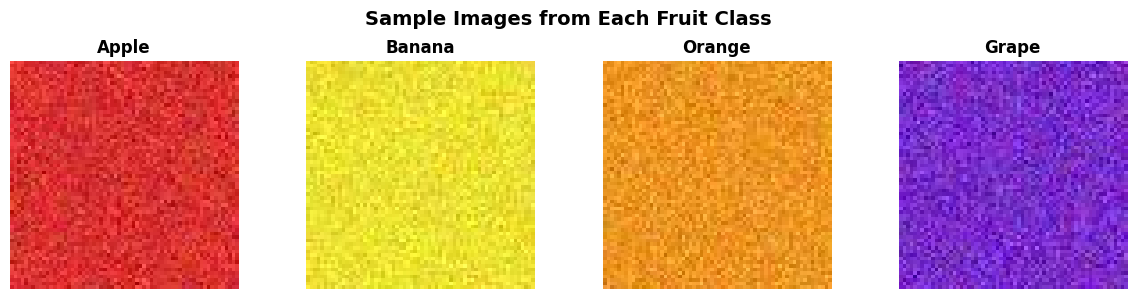

In [ ]:
def create_synthetic_fruit_dataset(base_path='fruit_dataset',
                                    n_samples_per_class=100,
                                    img_size=64):
    """
    Creates a synthetic fruit dataset with colored images.
    - Apple  → Reddish images
    - Banana → Yellowish images
    - Orange → Orangish images
    - Grape  → Purplish images

    In a real scenario, you would replace this with actual fruit images.
    """
    # Define fruit classes with their dominant RGB color ranges
    fruit_colors = {
        'apple':  {'r': (180, 255), 'g': (20,  80),  'b': (20,  80)},
        'banana': {'r': (220, 255), 'g': (200, 255), 'b': (20,  80)},
        'orange': {'r': (220, 255), 'g': (120, 180), 'b': (10,  60)},
        'grape':  {'r': (80,  160), 'g': (10,  80),  'b': (150, 255)},
    }

    splits = ['train', 'test']
    split_ratios = {'train': 0.8, 'test': 0.2}

    for split in splits:
        n = int(n_samples_per_class * split_ratios[split])
        for fruit, color_range in fruit_colors.items():
            folder = os.path.join(base_path, split, fruit)
            os.makedirs(folder, exist_ok=True)

            for i in range(n):
                # Create a random image with fruit's dominant color + noise
                img_array = np.zeros((img_size, img_size, 3), dtype=np.uint8)
                img_array[:, :, 0] = np.random.randint(color_range['r'][0], color_range['r'][1], (img_size, img_size))
                img_array[:, :, 1] = np.random.randint(color_range['g'][0], color_range['g'][1], (img_size, img_size))
                img_array[:, :, 2] = np.random.randint(color_range['b'][0], color_range['b'][1], (img_size, img_size))

                # Add some noise to make it more realistic
                noise = np.random.randint(-20, 20, (img_size, img_size, 3))
                img_array = np.clip(img_array.astype(int) + noise, 0, 255).astype(np.uint8)

                img = Image.fromarray(img_array)
                img.save(os.path.join(folder, f'{fruit}_{i:04d}.jpg'))

    print(f"✅ Synthetic dataset created at: '{base_path}/'")
    print(f"   Classes: {list(fruit_colors.keys())}")
    print(f"   Train samples per class: {int(n_samples_per_class * 0.8)}")
    print(f"   Test  samples per class: {int(n_samples_per_class * 0.2)}")
    return list(fruit_colors.keys())


# Create the dataset
class_names = create_synthetic_fruit_dataset()

# Visualize sample images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
fig.suptitle('Sample Images from Each Fruit Class', fontsize=14, fontweight='bold')

for idx, fruit in enumerate(class_names):
    img_path = os.path.join('fruit_dataset', 'train', fruit, f'{fruit}_0000.jpg')
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(fruit.capitalize(), fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

---
### 2.3 Writing a Custom Dataset Class

PyTorch requires your dataset to inherit from `torch.utils.data.Dataset` and implement **three methods**:

| Method | Purpose |
|--------|---------|
| `__init__` | Initialize paths, transforms, class labels |
| `__len__` | Return the total number of samples |
| `__getitem__` | Load and return a single sample by index |

In [ ]:
class FruitDataset(Dataset):
    """
    Custom Dataset class for loading fruit images from a directory.

    Directory structure expected:
        root_dir/
            apple/   → class 0
            banana/  → class 1
            orange/  → class 2
            grape/   → class 3
    """

    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir  (str)      : Path to folder containing class subfolders
            transform (callable) : Optional transform to apply on images
        """
        self.root_dir  = root_dir
        self.transform = transform

        # ── Step 1: Discover class names from folder names ──────────────────
        self.classes = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])

        # ── Step 2: Create class → index mapping ────────────────────────────
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

        # ── Step 3: Collect all image paths and their labels ─────────────────
        self.samples = []  # List of (image_path, label) tuples

        for class_name in self.classes:
            class_folder = os.path.join(root_dir, class_name)
            label = self.class_to_idx[class_name]

            for img_file in os.listdir(class_folder):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    img_path = os.path.join(class_folder, img_file)
                    self.samples.append((img_path, label))

        print(f"📁 Dataset loaded from  : {root_dir}")
        print(f"   Classes found        : {self.classes}")
        print(f"   Class → Index map    : {self.class_to_idx}")
        print(f"   Total images         : {len(self.samples)}")

    # ──────────────────────────────────────────────────────────────────────────
    def __len__(self):
        """Returns total number of samples in the dataset."""
        return len(self.samples)

    # ──────────────────────────────────────────────────────────────────────────
    def __getitem__(self, idx):
        """
        Loads and returns a single sample.

        Args:
            idx (int): Index of the sample to retrieve

        Returns:
            image (Tensor): Transformed image tensor
            label (int)   : Class index
        """
        img_path, label = self.samples[idx]

        # Load image using PIL (opens as RGB)
        image = Image.open(img_path).convert('RGB')

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label

    # ──────────────────────────────────────────────────────────────────────────
    def get_class_distribution(self):
        """Returns count of samples per class."""
        from collections import Counter
        label_counts = Counter([label for _, label in self.samples])
        return {self.idx_to_class[idx]: count for idx, count in sorted(label_counts.items())}


print("✅ FruitDataset class defined successfully!")

✅ FruitDataset class defined successfully!


---
### 2.4 Image Transforms & Augmentation

**Transforms** preprocess images before feeding them to the network.

| Transform | Purpose |
|-----------|----------|
| `Resize` | Standardize image dimensions |
| `ToTensor` | Convert PIL Image → Tensor (also scales 0-255 to 0.0-1.0) |
| `Normalize` | Zero-center pixel values for faster training |
| `RandomHorizontalFlip` | Data augmentation to prevent overfitting |
| `RandomRotation` | Data augmentation — rotate images randomly |

In [ ]:
# ── Constants ─────────────────────────────────────────────────────────────────
IMG_SIZE   = 64    # Resize all images to 64×64 pixels
BATCH_SIZE = 32    # Number of images per mini-batch

# ── ImageNet Mean & Std (commonly used for normalization) ─────────────────────
# These values normalize each channel (R, G, B) to have mean=0, std=1
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ── Training Transforms (with augmentation) ───────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # Step 1: Resize to fixed size
    # transforms.RandomHorizontalFlip(p=0.5),    # Step 2: Randomly flip (50% chance)
    # transforms.RandomRotation(degrees=15),     # Step 3: Random rotation ±15°
    # transforms.ColorJitter(brightness=0.2,     # Step 4: Random brightness/contrast
    #                        contrast=0.2),
    transforms.ToTensor(),                     # Step 5: Convert to Tensor [C, H, W]
    transforms.Normalize(MEAN, STD)            # Step 6: Normalize pixel values
])

# ── Validation/Test Transforms (NO augmentation) ──────────────────────────────
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # Only resize — no augmentation
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# ── Create Dataset Instances ──────────────────────────────────────────────────
print("\n📂 Loading TRAIN dataset...")
train_dataset = FruitDataset(root_dir='fruit_dataset/train', transform=train_transform)

print("\n📂 Loading TEST dataset...")
test_dataset  = FruitDataset(root_dir='fruit_dataset/test',  transform=test_transform)

# ── Class Distribution ────────────────────────────────────────────────────────
print("\n📊 Training class distribution:")
dist = train_dataset.get_class_distribution()
for cls, count in dist.items():
    bar = '█' * count
    print(f"   {cls:<8}: {bar} ({count})")


📂 Loading TRAIN dataset...
📁 Dataset loaded from  : fruit_dataset/train
   Classes found        : ['apple', 'banana', 'grape', 'orange']
   Class → Index map    : {'apple': 0, 'banana': 1, 'grape': 2, 'orange': 3}
   Total images         : 320

📂 Loading TEST dataset...
📁 Dataset loaded from  : fruit_dataset/test
   Classes found        : ['apple', 'banana', 'grape', 'orange']
   Class → Index map    : {'apple': 0, 'banana': 1, 'grape': 2, 'orange': 3}
   Total images         : 80

📊 Training class distribution:
   apple   : ████████████████████████████████████████████████████████████████████████████████ (80)
   banana  : ████████████████████████████████████████████████████████████████████████████████ (80)
   grape   : ████████████████████████████████████████████████████████████████████████████████ (80)
   orange  : ████████████████████████████████████████████████████████████████████████████████ (80)


---
### 2.5 Creating DataLoaders

**DataLoader** wraps a Dataset and provides:
- **Batching** – Groups samples into mini-batches
- **Shuffling** – Randomizes order each epoch (training only)
- **Parallel loading** – Uses multiple CPU workers to load data faster

```
Dataset[0]  ─┐
Dataset[1]  ─┤              ┌─────────────────────────────┐
Dataset[2]  ─┼─── shuffle ──► Batch: [img_0, img_1, img_2] ──► Model
    ...      ─┤              └─────────────────────────────┘
Dataset[N]  ─┘
```

In [ ]:
# ── Create DataLoaders ─────────────────────────────────────────────────────────
train_loader = DataLoader(
    dataset    = train_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = True,          # Shuffle training data each epoch
    num_workers= 0,             # Workers for parallel loading (0 = main thread)
    pin_memory = True if device.type == 'cuda' else False  # Faster GPU transfer
)

test_loader = DataLoader(
    dataset    = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,         # Do NOT shuffle test data
    num_workers= 0,
)

# ── Inspect a Batch ────────────────────────────────────────────────────────────
images, labels = next(iter(train_loader))

print("📦 One batch from DataLoader:")
print(f"   images.shape : {images.shape}  → [batch_size, channels, height, width]")
print(f"   labels.shape : {labels.shape}  → [batch_size]")
print(f"   Label values : {labels.tolist()}")
print(f"   Class names  : {[train_dataset.idx_to_class[l.item()] for l in labels[:8]]}")
print(f"   Pixel min    : {images.min():.3f}  (after normalization)")
print(f"   Pixel max    : {images.max():.3f}  (after normalization)")

📦 One batch from DataLoader:
   images.shape : torch.Size([32, 3, 64, 64])  → [batch_size, channels, height, width]
   labels.shape : torch.Size([32])  → [batch_size]
   Label values : [3, 2, 2, 0, 3, 2, 3, 2, 1, 1, 1, 3, 1, 1, 2, 2, 3, 1, 1, 3, 2, 2, 0, 3, 2, 3, 3, 2, 0, 1, 1, 2]
   Class names  : ['orange', 'grape', 'grape', 'apple', 'orange', 'grape', 'orange', 'grape']
   Pixel min    : -2.036  (after normalization)
   Pixel max    : 2.640  (after normalization)


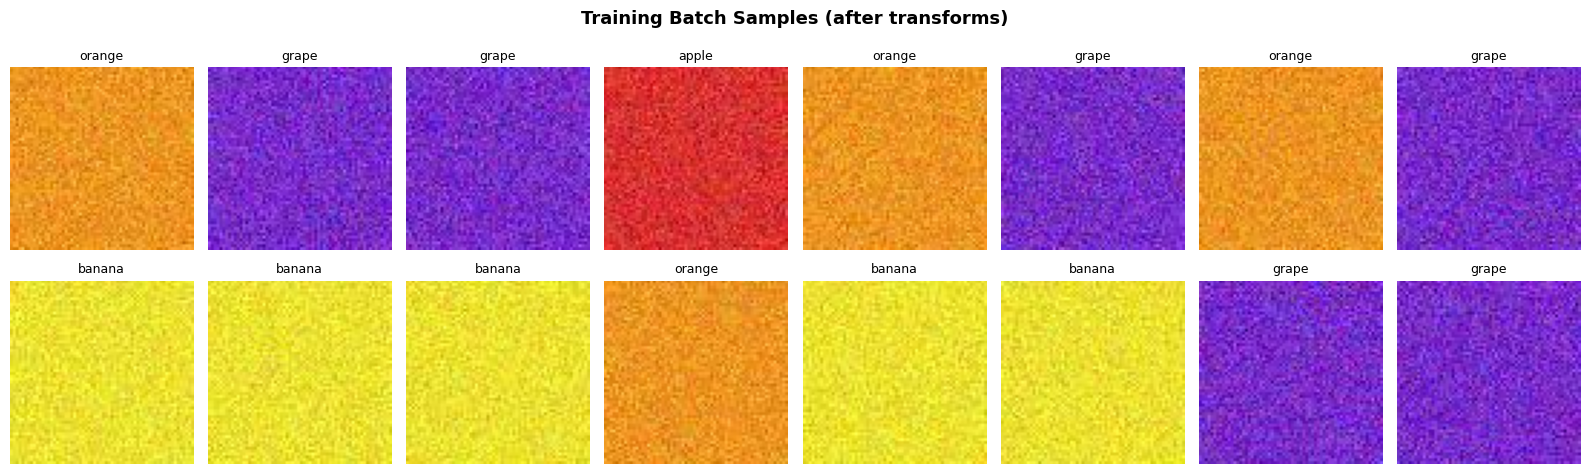


💡 Note: Images look slightly different due to augmentation (flip, rotation, color jitter)


In [ ]:
# ── Visualize a Batch ──────────────────────────────────────────────────────────
def denormalize(tensor, mean=MEAN, std=STD):
    """Reverse normalization for visualization."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Training Batch Samples (after transforms)', fontsize=13, fontweight='bold')

for i in range(16):
    row, col = divmod(i, 8)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[row, col].imshow(img)
    axes[row, col].set_title(train_dataset.idx_to_class[labels[i].item()], fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print("\n💡 Note: Images look slightly different due to augmentation (flip, rotation, color jitter)")

# Assignment is download the cifar 10 dataset in drive and load using the dataloader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


✅ Image '/content/drive/MyDrive/MTech_2025_executive/cat.jpeg' loaded successfully.


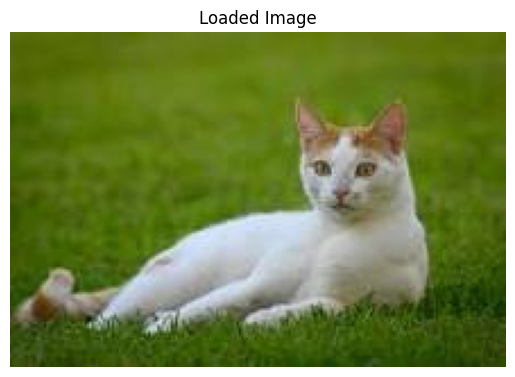

✅ Image transformed to tensor with shape: torch.Size([1, 3, 64, 64])
   Ready for CNN inference on device: cuda


In [ ]:
from PIL import Image
import torch
import matplotlib.pyplot as plt # Import matplotlib for visualization

# Define the image path
image_path = '/content/drive/MyDrive/MTech_2025_executive/cat.jpeg'

# Open the image using PIL
try:
    image = Image.open(image_path).convert('RGB')
    print(f"✅ Image '{image_path}' loaded successfully.")
except FileNotFoundError:
    print(f"❌ Error: Image not found at '{image_path}'. Please ensure the path is correct.")
    image = None

if image:
    # Display the original image
    plt.imshow(image)
    plt.title("Loaded Image")
    plt.axis('off')
    plt.show()

    # Apply the same transformations used for the test set
    # test_transform was defined earlier in the notebook
    image_tensor = test_transform(image)

    # Add a batch dimension (the model expects [batch_size, channels, height, width])
    image_tensor = image_tensor.unsqueeze(0)

    # Move the tensor to the correct device (CPU or GPU)
    # image_tensor = image_tensor.to(device)

    print(f"✅ Image transformed to tensor with shape: {image_tensor.shape}")
    print(f"   Ready for CNN inference on device: {device}")


---
## 🧠 Section 3: CNN Layers — Deep Dive

### 3.1 The Convolutional Layer (`nn.Conv2d`)

A **convolutional layer** slides a small **filter (kernel)** across the input image and computes dot products at each position.

`output_size = (I-K+2P)/s + 1`

here I is input size,K is kernel size, P is padding size and S is stride size

```
Input Image (5×5)      Filter (3×3)        Output Feature Map
┌─────────────────┐    ┌─────────┐         ┌─────────────┐
│ 1  2  3  0  1  │    │ 1  0 -1 │         │             │
│ 4  5  6  1  2  │  × │ 1  0 -1 │  ──►    │   3×3 map   │
│ 7  8  9  2  3  │    │ 1  0 -1 │         │             │
│ 1  1  1  1  1  │    └─────────┘         └─────────────┘
│ 2  2  2  2  2  │       Edge             Output size:
└─────────────────┘    Detector        (5-3+1) × (5-3+1) = 3×3
```

**Key parameters of `nn.Conv2d`:**
- `in_channels`  – Number of input channels (3 for RGB, 1 for grayscale)
- `out_channels` – Number of filters (= number of output feature maps)
- `kernel_size`  – Size of the filter (e.g., 3 means 3×3)
- `stride`       – How many pixels the filter moves per step (default=1)
- `padding`      – Zero-padding added to the border to control output size

In [ ]:
# ── Understanding Conv2d Output Size ──────────────────────────────────────────
# Formula: output_size = floor((input_size + 2*padding - kernel_size) / stride)+ 1

def conv_output_size(input_size, kernel_size, stride=1, padding=0):
    """Calculate the output spatial size after a Conv2d layer."""
    return (input_size + 2 * padding - kernel_size) // stride + 1

print("=" * 55)
print("  Conv2d Output Size Calculation")
print("=" * 55)

examples = [
    (64, 3, 1, 0, "Standard conv, no padding"),
    (64, 3, 1, 1, "Same conv (padding=1 keeps size)"),
    (64, 3, 2, 0, "Stride=2 (halves the size)"),
    (64, 5, 1, 2, "5×5 kernel with padding=2"),
]

for inp, k, s, p, desc in examples:
    out = conv_output_size(inp, k, s, p)
    print(f"  {desc}")
    print(f"    Input:{inp}×{inp}, Kernel:{k}×{k}, Stride:{s}, Pad:{p}  →  Output:{out}×{out}")
    print()

# ── Applying a Conv2d Layer ────────────────────────────────────────────────────
print("─" * 55)
print("  Example: Applying Conv2d to a batch")
print("─" * 55)

conv_layer = nn.Conv2d(in_channels=3,    # RGB input
                        out_channels=16,  # 16 different filters
                        kernel_size=3,    # 3×3 filter
                        stride=1,
                        padding=1)        # padding=1 preserves spatial size

# dummy_input = torch.randn(1, 3, 64, 64)  # batch=1, channels=3, H=64, W=64
conv_output = conv_layer(image_tensor)

print(f"  Input  shape: {list(image_tensor.shape)}  → [N, C_in, H, W]")
print(f"  Output shape: {list(conv_output.shape)} → [N, C_out, H_out, W_out]")
print(f"  Learnable parameters: {sum(p.numel() for p in conv_layer.parameters())}")
print(f"  (weights: 16×3×3×3={16*3*3*3}, biases: 16)")

  Conv2d Output Size Calculation
  Standard conv, no padding
    Input:64×64, Kernel:3×3, Stride:1, Pad:0  →  Output:62×62

  Same conv (padding=1 keeps size)
    Input:64×64, Kernel:3×3, Stride:1, Pad:1  →  Output:64×64

  Stride=2 (halves the size)
    Input:64×64, Kernel:3×3, Stride:2, Pad:0  →  Output:31×31

  5×5 kernel with padding=2
    Input:64×64, Kernel:5×5, Stride:1, Pad:2  →  Output:64×64

───────────────────────────────────────────────────────
  Example: Applying Conv2d to a batch
───────────────────────────────────────────────────────
  Input  shape: [1, 3, 64, 64]  → [N, C_in, H, W]
  Output shape: [1, 16, 64, 64] → [N, C_out, H_out, W_out]
  Learnable parameters: 448
  (weights: 16×3×3×3=432, biases: 16)


# Assignment 1

Add one more convolution method with strid 2 padding 2 and kernel size 4 and show the output size on given image

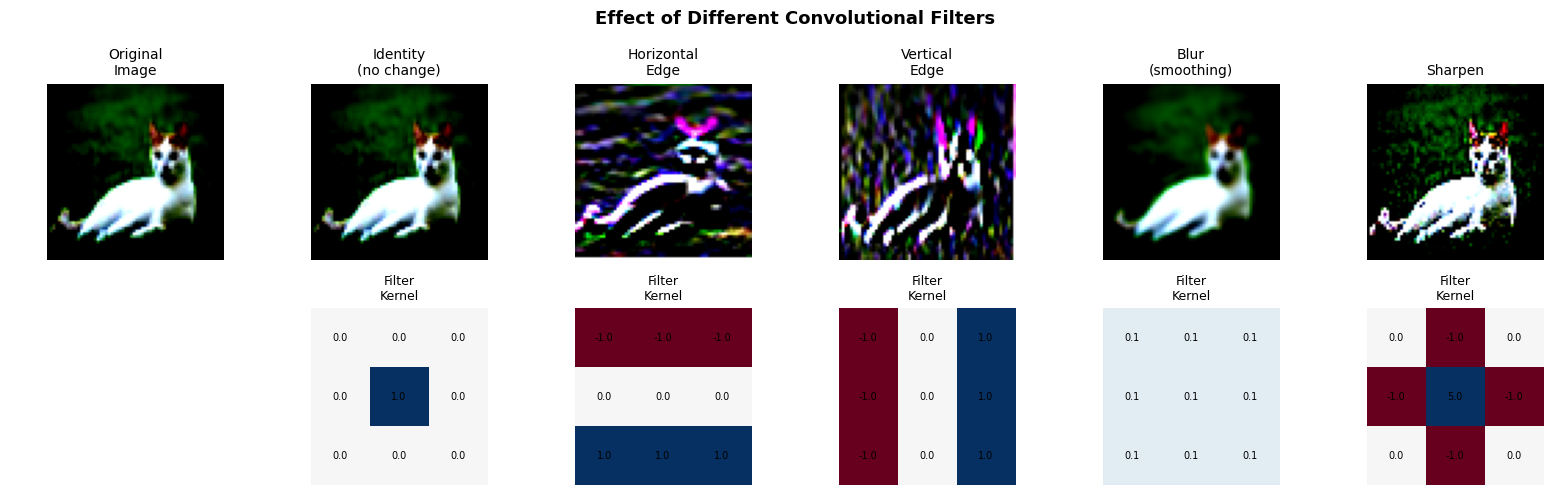


💡 Each filter learns to detect specific patterns. CNN learns these filters automatically!


In [ ]:
# ── Visualizing What Filters Detect ───────────────────────────────────────────
# Define some classical image processing filters
filters = {
    'Identity\n(no change)': torch.tensor([[0, 0, 0],
                                            [0, 1, 0],
                                            [0, 0, 0]], dtype=torch.float32),

    'Horizontal\nEdge': torch.tensor([[-1, -1, -1],
                                       [ 0,  0,  0],
                                       [ 1,  1,  1]], dtype=torch.float32),

    'Vertical\nEdge': torch.tensor([[-1, 0, 1],
                                     [-1, 0, 1],
                                     [-1, 0, 1]], dtype=torch.float32),

    'Blur\n(smoothing)': torch.ones(3, 3, dtype=torch.float32) / 9,

    'Sharpen': torch.tensor([[ 0, -1,  0],
                               [-1,  5, -1],
                               [ 0, -1,  0]], dtype=torch.float32),
}


test_img = image_tensor.squeeze(0)
test_img_batch = image_tensor  # Add batch dimension

fig, axes = plt.subplots(2, len(filters) + 1, figsize=(16, 5))
fig.suptitle('Effect of Different Convolutional Filters', fontsize=13, fontweight='bold')

# Show original
axes[0, 0].imshow(test_img.permute(1, 2, 0).numpy())
axes[0, 0].set_title('Original\nImage', fontsize=10)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for col, (name, kernel) in enumerate(filters.items(), start=1):
    # Apply filter to all 3 channels
    weight = kernel.view(1, 1, 3, 3).expand(3, 1, 3, 3).contiguous()
    conv = nn.Conv2d(3, 3, 3, padding=1, groups=3, bias=False)
    conv.weight = nn.Parameter(weight)

    with torch.no_grad():
        filtered = conv(test_img_batch).squeeze(0)

    # Show filter kernel
    axes[1, col].imshow(kernel.numpy(), cmap='RdBu', vmin=-1, vmax=1)
    axes[1, col].set_title('Filter\nKernel', fontsize=9)
    for i in range(3):
        for j in range(3):
            axes[1, col].text(j, i, f'{kernel[i,j]:.1f}', ha='center', va='center', fontsize=7)
    axes[1, col].axis('off')

    # Show output
    out_vis = torch.clamp(filtered, 0, 1).permute(1, 2, 0).detach().numpy()
    axes[0, col].imshow(out_vis)
    axes[0, col].set_title(name, fontsize=10)
    axes[0, col].axis('off')

plt.tight_layout()
plt.show()
print("\n💡 Each filter learns to detect specific patterns. CNN learns these filters automatically!")

# Assignment 2


Apply all the convolution kernels one after another in sequence on the given input image.
After applying each kernel, use the output feature map as the input for the next convolution.

Finally, show the output of the last convolution layer obtained after applying all kernels sequentially.

Steps to follow:

Start with the given input image (matrix).

Apply the first kernel and compute the output feature map.

Use this output as the input for the second kernel.

Continue this process for all given kernels in order.

Present the final output after the last convolution.

📌 Show all intermediate calculations clearly.

---
### 3.2 Activation Function — ReLU

After every convolutional layer, we apply a **non-linear activation function**.

The most common is **ReLU** (Rectified Linear Unit):

$$\text{ReLU}(x) = \max(0, x)$$

**Why do we need activation functions?**
> Without non-linearity, stacking multiple layers would still be a linear model. Activation functions let the network learn complex, non-linear patterns.

| Variant | Formula | Use case |
|---------|---------|----------|
| ReLU | max(0, x) | Most common, fast |
| LeakyReLU | max(0.01x, x) | Avoids dead neurons |
| Sigmoid | 1/(1+e^-x) | Binary classification output |
| Softmax | e^x / Σe^x | Multi-class output |

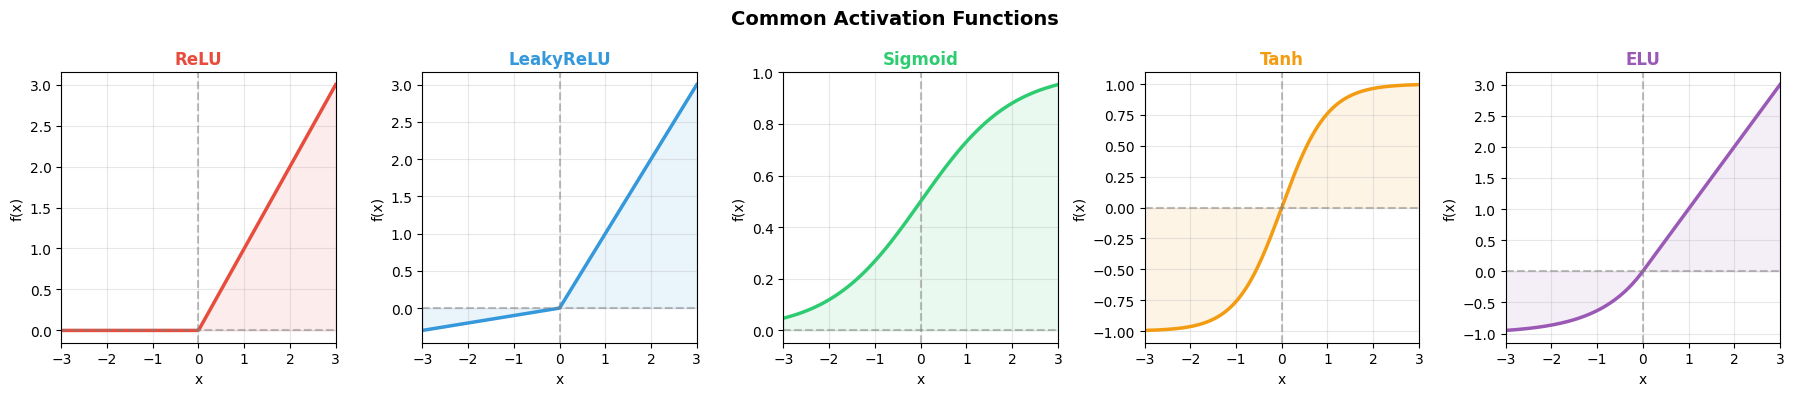

In [ ]:
# ── Visualize Activation Functions ────────────────────────────────────────────
x = torch.linspace(-3, 3, 200)

activations = {
    'ReLU':        F.relu(x),
    'LeakyReLU':   F.leaky_relu(x, 0.1),
    'Sigmoid':     torch.sigmoid(x),
    'Tanh':        torch.tanh(x),
    'ELU':         F.elu(x),
}

colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Common Activation Functions', fontsize=14, fontweight='bold')

for ax, (name, values), color in zip(axes, activations.items(), colors):
    ax.plot(x.numpy(), values.numpy(), color=color, linewidth=2.5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(x.numpy(), values.numpy(), alpha=0.1, color=color)
    ax.set_title(name, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-3, 3)

plt.tight_layout()
plt.show()

---
### 3.3 Pooling Layers — Reducing Spatial Dimensions

**Pooling** reduces the height and width of feature maps, which:
1. **Reduces computation** – smaller maps = fewer parameters
2. **Provides translation invariance** – small shifts in input → same output
3. **Controls overfitting** – fewer parameters to learn

#### Types of Pooling:

**Max Pooling** — Takes the maximum value in each window:
```
Input (4×4)              Max Pooling (2×2, stride=2)      Output (2×2)
┌────┬────┬────┬────┐                                    ┌────┬────┐
│  1 │  3 │  2 │  4 │    ┌────┬────┐   ┌────┬────┐     │  6 │  8 │
├────┼────┼────┼────┤    │ 1 3│ 2 4│   │ 5 7│ 6 8│     ├────┼────┤
│  5 │  6 │  7 │  8 │    │ 5 6│ 7 8│   │ 1 2│ 3 4│     │  7 │  8 │
├────┼────┼────┼────┤    └────┴────┘   └────┴────┘     └────┴────┘
│  1 │  2 │  3 │  1 │      max=6         max=8          max(region)
├────┼────┼────┼────┤
│  3 │  4 │  2 │  3 │
└────┴────┴────┴────┘
```

**Average Pooling** — Takes the average value in each window (preserves more texture information)

  Pooling Layer Demonstration

Input Feature Map (4×4):
[[1. 3. 2. 4.]
 [5. 6. 7. 8.]
 [1. 2. 3. 1.]
 [3. 4. 2. 3.]]

Max Pooling output (2×2, stride=2):
[[6. 8.]
 [4. 3.]]

Average Pooling output (2×2, stride=2):
[[3.75 5.25]
 [2.5  2.25]]

Global Average Pooling output (1×1):
  Single value: 3.44 (mean of entire map)


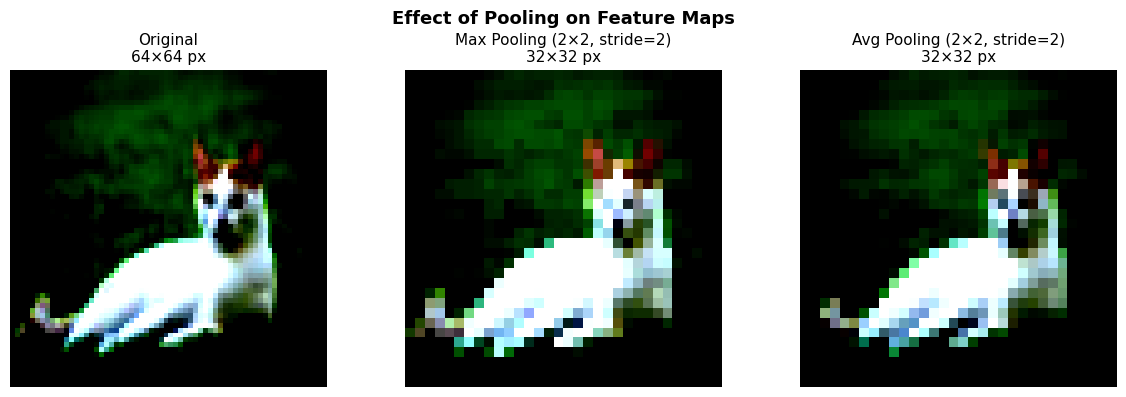


💡 Pooling halves the spatial dimension → reduces computation by 4×


In [ ]:
# ── Detailed Pooling Demonstration ────────────────────────────────────────────

# Create a sample 4×4 feature map
sample_fm = torch.tensor([[[[1, 3, 2, 4],
                              [5, 6, 7, 8],
                              [1, 2, 3, 1],
                              [3, 4, 2, 3]]]], dtype=torch.float32)

# Apply different pooling
max_pool    = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool    = nn.AvgPool2d(kernel_size=2, stride=2)
global_pool = nn.AdaptiveAvgPool2d(output_size=(1, 1))  # Outputs 1×1

print("=" * 50)
print("  Pooling Layer Demonstration")
print("=" * 50)
print(f"\nInput Feature Map (4×4):")
print(sample_fm[0, 0].numpy())

print(f"\nMax Pooling output (2×2, stride=2):")
out_max = max_pool(sample_fm)
print(out_max[0, 0].numpy())

print(f"\nAverage Pooling output (2×2, stride=2):")
out_avg = avg_pool(sample_fm)
print(out_avg[0, 0].numpy())

print(f"\nGlobal Average Pooling output (1×1):")
out_global = global_pool(sample_fm)
print(f"  Single value: {out_global[0, 0, 0, 0].item():.2f} (mean of entire map)")

# ── Visualize Pooling on a Real Image ─────────────────────────────────────────
img_tensor = test_img.unsqueeze(0)  # Add batch dim: [1, 3, 64, 64]

max_out = max_pool(img_tensor)
avg_out = avg_pool(img_tensor)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Effect of Pooling on Feature Maps', fontsize=13, fontweight='bold')

axes[0].imshow(img_tensor[0].permute(1, 2, 0).numpy())
axes[0].set_title(f'Original\n{img_tensor.shape[2]}×{img_tensor.shape[3]} px', fontsize=11)
axes[0].axis('off')

axes[1].imshow(max_out[0].permute(1, 2, 0).detach().numpy())
axes[1].set_title(f'Max Pooling (2×2, stride=2)\n{max_out.shape[2]}×{max_out.shape[3]} px', fontsize=11)
axes[1].axis('off')

axes[2].imshow(avg_out[0].permute(1, 2, 0).detach().numpy())
axes[2].set_title(f'Avg Pooling (2×2, stride=2)\n{avg_out.shape[2]}×{avg_out.shape[3]} px', fontsize=11)
axes[2].axis('off')

plt.tight_layout()
plt.show()
print("\n💡 Pooling halves the spatial dimension → reduces computation by 4×")

Assignment 3

Apply all the given convolution kernels sequentially on the input image. After each convolution operation, apply an activation function followed by a max pooling operation.

Steps to follow:

Start with the given input image (matrix).

Apply the first convolution kernel.

Apply an activation function (e.g., ReLU) to the convolution output.

Apply max pooling to the activated feature map.

Use the resulting output as the input for the next convolution kernel.

Repeat the same process for all kernels in sequence.

Show the final output after the last pooling layer.

📌 Show all intermediate feature maps and calculations clearly

---
### 3.4 Batch Normalization & Dropout

**Batch Normalization** (`nn.BatchNorm2d`):
- Normalizes feature maps within a batch
- Reduces internal covariate shift
- Allows higher learning rates → faster training

**Dropout** (`nn.Dropout`):
- Randomly sets neurons to zero during training
- Prevents over-reliance on specific neurons
- Acts as regularization to reduce overfitting

In [ ]:
# ── Demonstrate Batch Norm and Dropout ────────────────────────────────────────

print("📋 Batch Normalization Demo")
print("-" * 40)
bn_layer = nn.BatchNorm2d(num_features=16)  # normalize across 16 channels
x_bn = torch.randn(8, 16, 32, 32)           # batch=8, channels=16, 32×32 map

# Before BN
print(f"Before BN: mean={x_bn.mean():.3f}, std={x_bn.std():.3f}")

# After BN
bn_layer.train()
x_bn_out = bn_layer(x_bn)
print(f"After  BN: mean={x_bn_out.mean():.3f}, std={x_bn_out.std():.3f}")
print("  → Values re-normalized to near mean=0, std=1 per channel")

print("\n📋 Dropout Demo")
print("-" * 40)
dropout = nn.Dropout(p=0.5)  # 50% of neurons dropped

x_drop = torch.ones(1, 20)   # all ones

dropout.train()  # dropout is active during training
out_train = dropout(x_drop)
print(f"Training mode (p=0.5): {out_train.tolist()[0][:10]}")
print(f"  Zeros: {(out_train == 0).sum().item()}/20 values zeroed out")

dropout.eval()   # dropout is disabled during evaluation
out_eval = dropout(x_drop)
print(f"Eval mode: {out_eval.tolist()[0][:10]}")
print("  → All values preserved during evaluation")

📋 Batch Normalization Demo
----------------------------------------
Before BN: mean=0.004, std=1.002
After  BN: mean=0.000, std=1.000
  → Values re-normalized to near mean=0, std=1 per channel

📋 Dropout Demo
----------------------------------------
Training mode (p=0.5): [0.0, 2.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  Zeros: 10/20 values zeroed out
Eval mode: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  → All values preserved during evaluation


---
## 🏗️ Section 4: Building the CNN Architecture

### 4.1 CNN Architecture Overview

```
Input Image
[3 × 64 × 64]
      │
      ▼
┌─────────────────────────────────────────────────┐
│  CONV BLOCK 1                                   │
│  Conv2d(3→32, 3×3) → BN → ReLU → MaxPool(2×2) │
│  Output: [32 × 32 × 32]                         │
└─────────────────────────────────────────────────┘
      │
      ▼
┌─────────────────────────────────────────────────┐
│  CONV BLOCK 2                                   │
│  Conv2d(32→64, 3×3) → BN → ReLU → MaxPool(2×2)│
│  Output: [64 × 16 × 16]                         │
└─────────────────────────────────────────────────┘
      │
      ▼
┌─────────────────────────────────────────────────┐
│  CONV BLOCK 3                                   │
│  Conv2d(64→128, 3×3) → BN → ReLU → MaxPool(2×2)│
│  Output: [128 × 8 × 8]                          │
└─────────────────────────────────────────────────┘
      │
      ▼
  Flatten  →  [128 × 8 × 8 = 8192]
      │
      ▼
┌─────────────────────────────────────────────────┐
│  FULLY CONNECTED LAYERS                         │
│  Linear(8192→512) → ReLU → Dropout(0.5)         │
│  Linear(512→128)  → ReLU → Dropout(0.3)         │
│  Linear(128→4)    → (softmax applied in loss)   │
└─────────────────────────────────────────────────┘
      │
      ▼
 Output: [4 class scores]
 (apple, banana, orange, grape)
```

In [ ]:
class FruitCNN(nn.Module):
    """
    CNN for Fruit Classification.
    Input:  [batch, 3, 64, 64]  (RGB images, 64×64 pixels)
    Output: [batch, 4]          (logits for 4 fruit classes)
    """

    def __init__(self, num_classes=4):
        super(FruitCNN, self).__init__()
        self.covn1 = nn.Conv2d(3,64,3, padding=1)
        self.covn2 = nn.Conv2d(64,128,3, padding=1)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2,2)
        # Calculate the flattened size after two conv and pool layers
        # Input: 64x64
        # Conv1 (3x3, p=1): 64x64
        # MaxPool1 (2x2): 32x32
        # Conv2 (3x3, p=1): 32x32
        # MaxPool2 (2x2): 16x16
        # The number of channels after conv2 is 128
        self.fc1 = nn.Linear(128*16*16,512) # Corrected input features
        self.fc2 = nn.Linear(512,4)

    def forward(self, x):
      x1 = self.relu(self.covn1(x))

      max1 = self.maxpool(x1)
      # print(f"Shape after MaxPool1: {max1.shape}") # Debugging print
      x2 = self.relu(self.covn2(max1))

      max2 = self.maxpool(x2)
      # print(f"Shape after MaxPool2: {max2.shape}") # Debugging print

      # Flatten the tensor before passing to the linear layer
      # max2 is [batch_size, 128, 16, 16], flatten to [batch_size, 128 * 16 * 16]
      flattened = max2.view(max2.size(0), -1)
      # print(f"Shape after Flatten: {flattened.shape}") # Debugging print

      x3 = self.relu(self.fc1(flattened))
      # print(f"Shape after FC1 and ReLU: {x3.shape}") # Debugging print
      x4 = self.fc2(x3)
      return x4

model = FruitCNN(num_classes=len(class_names)).to(device)
print(model)


FruitCNN(
  (covn1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (covn2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=4, bias=True)
)


In [ ]:
NUM_EPOCHS   = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler: reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=3, factor=0.5)

In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # set to training mode (enables dropout, batch norm)
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # ── Forward pass ────────────────────────────
        optimizer.zero_grad()          # Reset gradients
        outputs = model(images)        # Get predictions
        loss = criterion(outputs, labels)  # Compute loss

        # ── Backward pass ───────────────────────────
        loss.backward()                # Compute gradients
        optimizer.step()               # Update weights

        # ── Metrics ─────────────────────────────────
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()  # set to eval mode (disables dropout, uses running BN stats)
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # No gradient computation needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


# ── Run Training ──────────────────────────────────────────────────────────────
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step(te_loss)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    test_losses.append(te_loss);  test_accs.append(te_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | {te_loss:>9.4f} | {te_acc:>7.2f}% | {current_lr:>8.6f}")

print("\n✅ Training complete!")

 Epoch | Train Loss | Train Acc | Test Loss | Test Acc |       LR
-----------------------------------------------------------------
     1 |     0.7099 |    78.44% |    0.0170 |  100.00% | 0.001000
     2 |     0.0019 |   100.00% |    0.0000 |  100.00% | 0.001000
     3 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.001000
     4 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.001000
     5 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.001000
     6 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.001000
     7 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000500
     8 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000500
     9 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000500
    10 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000500
    11 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000250
    12 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000250
    13 |     0.0000 |   100.00% |    0.0000 |  100.00% | 0.000250
    14 |  

In [ ]:
# class FruitCNN(nn.Module):
#     """
#     CNN for Fruit Classification.
#     Input:  [batch, 3, 64, 64]  (RGB images, 64×64 pixels)
#     Output: [batch, 4]          (logits for 4 fruit classes)
#     """

#     def __init__(self, num_classes=4):
#         super(FruitCNN, self).__init__()

#         # ── FEATURE EXTRACTOR ────────────────────────────────────────────────
#         # Composed of Convolutional Blocks: Conv → BN → ReLU → MaxPool

#         # Block 1: 3 → 32 channels,  64×64 → 32×32
#         self.block1 = nn.Sequential(
#             nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)   # halves H and W
#         )

#         # Block 2: 32 → 64 channels,  32×32 → 16×16
#         self.block2 = nn.Sequential(
#             nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
#         )

#         # Block 3: 64 → 128 channels,  16×16 → 8×8
#         self.block3 = nn.Sequential(
#             nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
#         )

#         # ── CLASSIFIER HEAD ──────────────────────────────────────────────────
#         # After 3 poolings: 64×64 → 32×32 → 16×16 → 8×8
#         # Feature map size: 128 channels × 8 × 8 = 8192 values

#         self.classifier = nn.Sequential(
#             nn.Flatten(),                             # [N, 128, 8, 8] → [N, 8192]
#             nn.Linear(128 * 8 * 8, 512),
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.5),                        # 50% dropout for regularization
#             nn.Linear(512, 128),
#             nn.ReLU(inplace=True),
#             nn.Dropout(p=0.3),                        # 30% dropout
#             nn.Linear(128, num_classes)               # Final output logits
#         )

#     def forward(self, x):
#         """
#         Forward pass through the network.
#         Args:
#             x: Input tensor of shape [N, 3, 64, 64]
#         Returns:
#             logits: Raw scores of shape [N, num_classes]
#         """
#         # Feature extraction
#         x = self.block1(x)   # [N, 32, 32, 32]
#         x = self.block2(x)   # [N, 64, 16, 16]
#         x = self.block3(x)   # [N, 128, 8, 8]

#         # Classification
#         x = self.classifier(x)  # [N, num_classes]
#         return x


# # ── Instantiate the Model ─────────────────────────────────────────────────────
# model = FruitCNN(num_classes=len(class_names)).to(device)
# print(model)

In [ ]:
# ── Model Summary ─────────────────────────────────────────────────────────────
print("=" * 60)
print("  FruitCNN Architecture — Layer-by-Layer Summary")
print("=" * 60)

# Trace shapes through the network manually
dummy = torch.randn(1, 3, 64, 64).to(device)

with torch.no_grad():
    print(f"  Input               : {list(dummy.shape)}")
    out1 = model.block1(dummy)
    print(f"  After Block 1       : {list(out1.shape)}  ← 3→32ch, 64→32px")
    out2 = model.block2(out1)
    print(f"  After Block 2       : {list(out2.shape)}  ← 32→64ch, 32→16px")
    out3 = model.block3(out2)
    print(f"  After Block 3       : {list(out3.shape)} ← 64→128ch, 16→8px")

    flat = nn.Flatten()(out3)
    print(f"  After Flatten       : {list(flat.shape)}      ← 128×8×8={128*8*8}")

    final = model(dummy)
    print(f"  Output (logits)     : {list(final.shape)}         ← {len(class_names)} class scores")

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print()
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable params    : {trainable_params:,}")
print(f"  Model size (approx) : {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

---
## 🔁 Section 5: Training the CNN

### 5.1 Loss Function & Optimizer

- **CrossEntropyLoss** — Standard loss for multi-class classification. Combines `Softmax + NegativeLogLikelihood`.
- **Adam optimizer** — Adaptive learning rate optimizer; works well out of the box.

In [ ]:
# ── Training Configuration ────────────────────────────────────────────────────
NUM_EPOCHS   = 15
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler: reduce LR when val loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=3, factor=0.5)

print("✅ Training setup complete:")
print(f"   Loss function : CrossEntropyLoss")
print(f"   Optimizer     : Adam (lr={LEARNING_RATE}, weight_decay=1e-4)")
print(f"   LR Scheduler  : ReduceLROnPlateau")
print(f"   Epochs        : {NUM_EPOCHS}")

In [ ]:
# ── Training Loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()  # set to training mode (enables dropout, batch norm)
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        # ── Forward pass ────────────────────────────
        optimizer.zero_grad()          # Reset gradients
        outputs = model(images)        # Get predictions
        loss = criterion(outputs, labels)  # Compute loss

        # ── Backward pass ───────────────────────────
        loss.backward()                # Compute gradients
        optimizer.step()               # Update weights

        # ── Metrics ─────────────────────────────────
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()  # set to eval mode (disables dropout, uses running BN stats)
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # No gradient computation needed
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


# ── Run Training ──────────────────────────────────────────────────────────────
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Loss':>9} | {'Test Acc':>8} | {'LR':>8}")
print("-" * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step(te_loss)

    train_losses.append(tr_loss); train_accs.append(tr_acc)
    test_losses.append(te_loss);  test_accs.append(te_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | {te_loss:>9.4f} | {te_acc:>7.2f}% | {current_lr:>8.6f}")

print("\n✅ Training complete!")

In [ ]:
# ── Plot Training History ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

epochs = range(1, NUM_EPOCHS + 1)

# Loss plot
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs, test_losses,  'r-o', label='Test Loss',  markersize=4)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs, train_accs, 'b-o', label='Train Accuracy', markersize=4)
axes[1].plot(epochs, test_accs,  'r-o', label='Test Accuracy',  markersize=4)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

---
## 📊 Section 6: Evaluation & Visualization

### 6.1 Confusion Matrix

In [ ]:
# ── Collect Predictions ───────────────────────────────────────────────────────
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Classification Report ─────────────────────────────────────────────────────
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

---
### 6.2 Visualizing Feature Maps

We can look **inside** the CNN to see what each layer has learned to detect.

In [ ]:
# ── Extract and Visualize Feature Maps ────────────────────────────────────────
def visualize_feature_maps(model, input_tensor, layer_name, max_filters=16):
    """Visualize feature maps from a specific layer."""

    activation = {}

    def hook_fn(module, input, output):
        activation['feature_map'] = output.detach()

    # Register hook
    hook = getattr(model, layer_name).register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(input_tensor)

    hook.remove()

    fm = activation['feature_map'][0]  # Remove batch dim
    n_filters = min(fm.shape[0], max_filters)

    cols = 8
    rows = (n_filters + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 1.8))
    fig.suptitle(f'Feature Maps — {layer_name} ({fm.shape[0]} filters, showing {n_filters})',
                 fontsize=12, fontweight='bold')

    if rows == 1: axes = axes.reshape(1, -1)

    for i in range(rows * cols):
        row, col = divmod(i, cols)
        ax = axes[row, col]
        if i < n_filters:
            ax.imshow(fm[i].cpu().numpy(), cmap='viridis')
            ax.set_title(f'Filter {i+1}', fontsize=7)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    return fm


# Load a sample image from the test set
sample_img, sample_lbl = test_dataset[0]
sample_input = sample_img.unsqueeze(0).to(device)

print(f"Input image class: {class_names[sample_lbl]}")
print()

# Visualize feature maps from each block
for block_name in ['block1', 'block2', 'block3']:
    fm = visualize_feature_maps(model, sample_input, block_name)
    print(f"{block_name}: {tuple(fm.shape)} feature maps (channels × H × W)")
    print()

---
## 📝 Section 7: In-Class Assignments

---

### ✏️ Assignment 1 — Modify the Dataset Pipeline
**Difficulty: ⭐ Beginner**

**Task:** Extend the `FruitDataset` class to:
1. Add a method `get_sample_image(class_name)` that returns a PIL image from a specific class.
2. Add support for loading `.png` and `.bmp` files in addition to `.jpg`.
3. Print the **total file size (in MB)** of the dataset in `__init__`.

> **Hint:** Use `os.path.getsize()` to get file sizes.

In [ ]:
# ── YOUR CODE HERE: Assignment 1 ──────────────────────────────────────────────

class FruitDatasetV2(Dataset):
    """
    Extended FruitDataset — complete the TODO sections.
    """

    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform

        self.classes = sorted([d for d in os.listdir(root_dir)
                                if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}

        self.samples = []
        # TODO: Add support for .png and .bmp files (currently only .jpg, .jpeg)
        VALID_EXTENSIONS = ('.jpg', '.jpeg')  # ← ADD .png and .bmp here

        total_size_bytes = 0
        for class_name in self.classes:
            class_folder = os.path.join(root_dir, class_name)
            label = self.class_to_idx[class_name]
            for img_file in os.listdir(class_folder):
                if img_file.lower().endswith(VALID_EXTENSIONS):
                    img_path = os.path.join(class_folder, img_file)
                    self.samples.append((img_path, label))
                    # TODO: Add file size to total_size_bytes

        # TODO: Print total dataset size in MB
        # print(f"   Dataset size: ??? MB")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

    def get_sample_image(self, class_name):
        """
        TODO: Return the first PIL image from the given class_name.
        Raise ValueError if class_name is not valid.
        """
        pass  # ← IMPLEMENT THIS


# ── Test your implementation ───────────────────────────────────────────────────
# ds_v2 = FruitDatasetV2(root_dir='fruit_dataset/train', transform=test_transform)
# img = ds_v2.get_sample_image('apple')
# print(type(img))  # Should print: <class 'PIL.Image.Image'>

---
### ✏️ Assignment 2 — Experiment with Conv2d Parameters
**Difficulty: ⭐⭐ Intermediate**

**Task:** Explore how `kernel_size`, `stride`, and `padding` affect the output.

Fill in the table below by running the experiments:

| Input Size | kernel_size | stride | padding | Expected Output Size | Actual Output Size |
|-----------|------------|--------|---------|---------------------|--------------------|
| 32×32     | 3          | 1      | 0       | ?                   | ?                  |
| 32×32     | 3          | 1      | 1       | ?                   | ?                  |
| 32×32     | 5          | 2      | 0       | ?                   | ?                  |
| 32×32     | 7          | 1      | 3       | ?                   | ?                  |

1. Use the formula: `output = floor((input + 2*padding - kernel) / stride) + 1`
2. Verify by actually running `nn.Conv2d` with a dummy tensor

In [ ]:
# ── YOUR CODE HERE: Assignment 2 ──────────────────────────────────────────────

experiments = [
    # (input_size, kernel_size, stride, padding)
    (32, 3, 1, 0),
    (32, 3, 1, 1),
    (32, 5, 2, 0),
    (32, 7, 1, 3),
]

print(f"{'Input':>8} | {'Kernel':>8} | {'Stride':>8} | {'Pad':>6} | {'Expected':>10} | {'Actual':>10}")
print("-" * 68)

for inp, k, s, p in experiments:
    # TODO: Calculate expected output using the formula
    expected = None  # ← REPLACE with formula

    # TODO: Create a dummy tensor and pass through Conv2d to get actual output
    actual = None    # ← REPLACE with actual Conv2d output shape

    print(f"  {inp}×{inp}  |   {k}×{k}   |       {s}  |    {p}  | {str(expected):>10} | {str(actual):>10}")

---
### ✏️ Assignment 3 — Build a Deeper CNN
**Difficulty: ⭐⭐ Intermediate**

**Task:** Modify `FruitCNN` to create `FruitCNNDeep` with:
1. **4 convolutional blocks** (add a Block 4: 128→256 channels)
2. Use **Global Average Pooling** (`nn.AdaptiveAvgPool2d`) instead of `Flatten` before the classifier
3. Reduce the FC layers to just one: `Linear(256, num_classes)`
4. Print the total parameter count and compare with `FruitCNN`

> **Tip:** Global Average Pooling outputs shape `[N, C, 1, 1]`. Flatten it to `[N, C]`.

In [ ]:
# ── YOUR CODE HERE: Assignment 3 ──────────────────────────────────────────────

class FruitCNNDeep(nn.Module):
    """
    Deeper CNN with 4 conv blocks and Global Average Pooling.
    TODO: Implement this class.
    """

    def __init__(self, num_classes=4):
        super(FruitCNNDeep, self).__init__()

        # TODO: Add block1, block2, block3 (same as FruitCNN)
        # TODO: Add block4 (128 → 256 channels, with MaxPool)
        # TODO: Add Global Average Pooling layer
        # TODO: Add classifier: just Linear(256, num_classes)
        pass

    def forward(self, x):
        # TODO: Implement the forward pass
        pass


# Test
# model_deep = FruitCNNDeep(num_classes=4)
# out = model_deep(torch.randn(1, 3, 64, 64))
# print(f"Output shape: {out.shape}")  # Should be [1, 4]
#
# orig_params = sum(p.numel() for p in model.parameters())
# deep_params = sum(p.numel() for p in model_deep.parameters())
# print(f"FruitCNN params    : {orig_params:,}")
# print(f"FruitCNNDeep params: {deep_params:,}")

---
### ✏️ Assignment 4 — Compare Max vs Average Pooling
**Difficulty: ⭐⭐⭐ Advanced**

**Task:**
1. Create two identical CNNs — one using `MaxPool2d` and one using `AvgPool2d`
2. Train both for **5 epochs** on the fruit dataset
3. Plot their training & test accuracy curves on the same graph
4. Write 2-3 sentences explaining which performed better and **why** you think that is

> **Expected outcome:** MaxPool often works better for texture/edge features; AvgPool can sometimes be better for smooth features.

In [ ]:
# ── YOUR CODE HERE: Assignment 4 ──────────────────────────────────────────────

class FruitCNN_MaxPool(nn.Module):
    """TODO: Implement identical to FruitCNN but explicitly uses MaxPool2d"""
    pass

class FruitCNN_AvgPool(nn.Module):
    """TODO: Implement identical to FruitCNN but uses AvgPool2d instead"""
    pass


# TODO:
# 1. Instantiate both models
# 2. Train both for 5 epochs (reuse train_one_epoch and evaluate functions)
# 3. Plot accuracies on the same graph
# 4. Print your analysis


# YOUR ANALYSIS (write as a comment or markdown cell):
# Which pooling performed better? Why?
# ...
# ...
# ...

In [ ]:
# ── Save the trained model ────────────────────────────────────────────────────
torch.save({
    'epoch'            : NUM_EPOCHS,
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses'     : train_losses,
    'test_losses'      : test_losses,
    'train_accs'       : train_accs,
    'test_accs'        : test_accs,
    'class_names'      : class_names,
}, 'fruit_cnn_checkpoint.pth')

print("✅ Model saved to 'fruit_cnn_checkpoint.pth'")
print()
print("To load the model later:")
print("""
checkpoint = torch.load('fruit_cnn_checkpoint.pth')
model = FruitCNN(num_classes=4)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Set to evaluation mode
""")